## Contents

1. [Fundamentals of LS and TLS ESPRIT](#fundamentals-of-ls-and-tls-esprit)
2. [ESPRIT Performance](#esprit-performance)
   1. [Probability of Resolution vs ASNR](#probability-of-resolution-vs-asnr)
   2. [DoA Estimation Accuracy vs ASNR](#doa-estimation-accuracy-vs-asnr)
   3. [Validation Results with AWR2243](#validation-results-with-awr2243)

<a id="fundamentals-of-ls-and-tls-esprit"></a>

## Fundamentals of LS and TLS ESPRIT

**ESPRIT (Estimation of Signal Parameters via Rotational Invariance Techniques)** is a subspace-based DoA estimation method for shift-invariant arrays such as a uniform linear array (ULA). Its key idea is that two overlapping subarrays observe the same targets, but with deterministic phase shifts that depend on the directions of arrival.

For an $M$-element ULA with spacing $d$, the steering vector of a signal arriving from angle $\theta$ is

$$
\mathbf{a}(\theta)
=

\begin{bmatrix}
1 &
e^{j\mu} &
e^{j2\mu} &
\cdots &
e^{j(M-1)\mu}
\end{bmatrix}^{T},
\qquad
\mu = \frac{2\pi d}{\lambda}\sin\theta,
$$

with

$$
\mathbf{a}(\theta)\in\mathbb{C}^{M\times 1}.
$$

Two overlapping $(M-1)$-element subarrays are formed by removing the last and first array element, respectively:

<p align="center">
  <img
    src="../docs/images/esprit_shift_invariance.png"
    alt="Overlapping subarrays used by ESPRIT"
    width="65%">
</p>

Their steering vectors are

$$
\mathbf{a}_1(\theta)
=

\begin{bmatrix}
1 &
e^{j\mu} &
\cdots &
e^{j(M-2)\mu}
\end{bmatrix}^{T},
$$

$$
\mathbf{a}_2(\theta)
=

\begin{bmatrix}
e^{j\mu} &
e^{j2\mu} &
\cdots &
e^{j(M-1)\mu}
\end{bmatrix}^{T},
$$

with

$$
\mathbf{a}_1(\theta),
\mathbf{a}_2(\theta)
\in
\mathbb{C}^{(M-1)\times 1}.
$$

The second subarray differs from the first only by a phase factor:

$$
\mathbf{a}_2(\theta)
=

\mathbf{a}_1(\theta)e^{j\mu}.
$$

This phase shift contains the DoA information because

$$
\mu = \frac{2\pi d}{\lambda}\sin\theta.
$$

For multiple targets, each source contributes its own phase shift. ESPRIT estimates these phase shifts from the signal subspace rather than from a scanned angular spectrum.

In practice, the steering vectors are not known directly. ESPRIT starts from spatial snapshots

$$
\mathbf{x}[\ell]\in\mathbb{C}^{M\times 1}
$$

and estimates the sample covariance matrix

$$
\hat{\mathbf{R}}
=

\frac{1}{L}
\sum_{\ell=0}^{L-1}
\mathbf{x}[\ell]\mathbf{x}^{H}[\ell],
$$

where

$$
\hat{\mathbf{R}}\in\mathbb{C}^{M\times M}.
$$

Its eigendecomposition is

$$
\hat{\mathbf{R}}
=

\mathbf{E}\mathbf{\Lambda}\mathbf{E}^{H},
$$

with

$$
\mathbf{E}\in\mathbb{C}^{M\times M},
\qquad
\mathbf{\Lambda}\in\mathbb{R}^{M\times M}.
$$

If $K$ targets are present, the eigenvectors corresponding to the $K$ largest eigenvalues form the **signal subspace**

$$
\mathbf{E}_s
=

\begin{bmatrix}
\mathbf{e}_1 &
\mathbf{e}_2 &
\cdots &
\mathbf{e}_K
\end{bmatrix},
$$

with

$$
\mathbf{E}_s \in \mathbb{C}^{M\times K}.
$$

The same subarray partitioning is then applied to the signal subspace:

$$
\mathbf{E}_1
=

\mathbf{E}_s(1:M-1,:),
\qquad
\mathbf{E}_2
=

\mathbf{E}_s(2:M,:),
$$

where

$$
\mathbf{E}_1,
\mathbf{E}_2
\in
\mathbb{C}^{(M-1)\times K}.
$$

For a shift-invariant array,

$$
\mathbf{E}_2
\approx
\mathbf{E}_1\mathbf{\Psi},
$$

where

$$
\mathbf{\Psi}\in\mathbb{C}^{K\times K}
$$

is the rotational-invariance matrix. Its eigenvalues contain the source-dependent phase shifts.

### LS-ESPRIT

In **Least-Squares ESPRIT**, $\mathbf{E}_1$ is treated as the reference matrix and the transformation is estimated by minimizing

$$
\left|
\mathbf{E}_2
-

\mathbf{E}_1\mathbf{\Psi}
\right|_F^2.
$$

The LS solution is

$$
\mathbf{\Psi}_{LS}
=

\mathbf{E}_1^{\dagger}\mathbf{E}_2,
$$

where

$$
\mathbf{E}_1^{\dagger}
\in
\mathbb{C}^{K\times(M-1)}
$$

is the Moore–Penrose pseudoinverse.

Therefore,

$$
\mathbf{\Psi}_{LS}
\in
\mathbb{C}^{K\times K}.
$$

Since $\mathbf{E}_1$ is normally a tall rectangular matrix, the pseudoinverse provides the least-squares solution to the overdetermined system

$$
\mathbf{E}_1\mathbf{\Psi}
\approx
\mathbf{E}_2.
$$

For full column rank,

$$
\mathbf{E}_1^{\dagger}
=

\left(
\mathbf{E}_1^H\mathbf{E}_1
\right)^{-1}
\mathbf{E}_1^H.
$$

Thus,

$$
\mathbf{\Psi}_{LS}
=

\left(
\mathbf{E}_1^H\mathbf{E}_1
\right)^{-1}
\mathbf{E}_1^H\mathbf{E}_2.
$$

### TLS-ESPRIT

In **Total Least-Squares ESPRIT**, both $\mathbf{E}_1$ and $\mathbf{E}_2$ are treated as noisy estimates. They are first combined into the augmented matrix

$$
\mathbf{Z}
=
\begin{bmatrix}
\mathbf{E}_1 & \mathbf{E}_2
\end{bmatrix},
$$

with

$$
\mathbf{Z}
\in
\mathbb{C}^{(M-1)\times 2K}.
$$

Instead of applying SVD directly to $\mathbf{Z}$, the TLS formulation forms the square Hermitian matrix

$$
\tilde{\mathbf{C}}
=
\mathbf{Z}^{H}\mathbf{Z}
=
\begin{bmatrix}
\mathbf{E}_1^{H} \
\mathbf{E}_2^{H}
\end{bmatrix}
\begin{bmatrix}
\mathbf{E}_1 & \mathbf{E}_2
\end{bmatrix},
$$

with

$$
\tilde{\mathbf{C}}
\in
\mathbb{C}^{2K\times 2K}.
$$

Its eigendecomposition is

$$
\tilde{\mathbf{C}}
=
\mathbf{V}
\mathbf{\Lambda}_{E}
\mathbf{V}^{H},
$$

where

$$
\mathbf{V}
\in
\mathbb{C}^{2K\times 2K},
\qquad
\mathbf{\Lambda}_{E}
\in
\mathbb{R}^{2K\times 2K}.
$$

The eigenvalues are ordered as

$$
\lambda_{E1}
\ge
\lambda_{E2}
\ge
\cdots
\ge
\lambda_{E,2K}.
$$

The eigenvectors corresponding to the smallest $K$ eigenvalues describe the approximate joint dependency between the two noisy subarray signal-subspace matrices.

The matrix $\mathbf{V}$ is partitioned into four $K\times K$ blocks:

$$
\mathbf{V}
=
\begin{bmatrix}
\mathbf{V}_{11} & \mathbf{V}_{12} \
\mathbf{V}_{21} & \mathbf{V}_{22}
\end{bmatrix},
$$

where

$$
\mathbf{V}_{11},
\mathbf{V}_{12},
\mathbf{V}_{21},
\mathbf{V}_{22}
\in
\mathbb{C}^{K\times K}.
$$

The eigenvectors associated with the smallest $K$ eigenvalues form the right block

$$
\mathbf{V}_{\min}
=
\begin{bmatrix}
\mathbf{V}_{12} \
\mathbf{V}_{22}
\end{bmatrix}
\in
\mathbb{C}^{2K\times K}.
$$

The TLS rotational-invariance matrix is then recovered as

$$
\mathbf{\Psi}_{TLS}
=
-\mathbf{V}_{12}
\mathbf{V}_{22}^{-1},
$$

with

$$
\mathbf{\Psi}_{TLS}
\in
\mathbb{C}^{K\times K}.
$$

Thus, LS estimates the transformation by fitting $\mathbf{E}_2$ to $\mathbf{E}_1$, while TLS estimates the joint relation between two noisy subarray subspaces through the eigenspace of the augmented matrix $\mathbf{Z}^{H}\mathbf{Z}$.

### DoA Extraction

For both LS- and TLS-ESPRIT, the final processing is identical. The rotational-invariance matrix

$$
\mathbf{\Psi}
\in
\mathbb{C}^{K\times K}
$$

is decomposed as

$$
\mathbf{\Psi}\mathbf{q}_k
=

\lambda_k\mathbf{q}_k.
$$

Its $K$ eigenvalues are

$$
\lambda_k
=

e^{j\mu_k},
\qquad
k=1,\ldots,K.
$$

The spatial phase shifts are therefore obtained from

$$
\mu_k
=

\arg(\lambda_k),
$$

and the DoAs are

$$
\theta_k
=

\arcsin\left(
\frac{\lambda}{2\pi d}
\arg(\lambda_k)
\right).
$$

For the common half-wavelength spacing $d=\lambda/2$, this simplifies to

$$
\theta_k
=

\arcsin\left(
\frac{\arg(\lambda_k)}{\pi}
\right).
$$

The complete processing flow is therefore

$$
\hat{\mathbf{R}}
\rightarrow
\mathbf{E}_s
\rightarrow
\mathbf{E}_1,\mathbf{E}_2
\rightarrow
\mathbf{\Psi}_{LS}
\ \text{or}
\mathbf{\Psi}_{TLS}
\rightarrow
\operatorname{eig}(\mathbf{\Psi})
\rightarrow
\arg(\lambda_k)
\rightarrow
\theta_k.
$$

In this way, both LS- and TLS-ESPRIT estimate target directions directly from rotational invariance of the covariance-derived signal subspace, without angular scanning or spectrum peak search.


<a id="esprit-performance"></a>

## ESPRIT Performance

The performance analysis of ESPRIT considers both its statistical behavior under controlled simulation conditions and its practical behavior with real radar measurements.

The simulation-based analysis evaluates the algorithm over different SNR values using two numerical metrics:

* **Probability of resolution versus SNR**, which characterizes how reliably ESPRIT separates two closely spaced sources.
* **RMSE versus SNR**, which characterizes the accuracy of the estimated DoAs relative to the known source directions.

These simulations provide controlled evaluation of the estimator as the measurement conditions degrade or improve.

The practical performance is then demonstrated using measurements acquired with the **AWR2243** radar. The measured DoA estimates are used to verify how the theoretical behavior of ESPRIT translates to a real FMCW MIMO radar array.


<a id="probability-of-resolution-vs-asnr"></a>

### Probability of Resolution vs ASNR

The resolution performance of LS- and TLS-ESPRIT is evaluated using Monte Carlo simulation with two equal-power, uncorrelated sources.

The source separation follows the reference separation used by Van Trees,

$$
\Delta\psi=\Delta\psi_R,
\qquad
\Delta\psi_R = 0.2165,BW_{NN},
$$

where $BW_{NN}$ is the null-to-null beamwidth of the conventional beam pattern. For an $N$-element ULA,

$$
BW_{NN}\approx\frac{4\pi}{N},
$$

so

$$
\Delta\psi_R
\approx
0.2165,\frac{4\pi}{N}.
$$

This reference separation is approximately one half of the conventional half-power beamwidth. The two sources are located symmetrically at

$$
\psi_1=-\frac{\Delta\psi_R}{2},
\qquad
\psi_2=+\frac{\Delta\psi_R}{2}.
$$

The **array signal-to-noise ratio (ASNR)** used in the simulation is

$$
\mathrm{ASNR}
=
\frac{N P_s}{\sigma_n^2},
$$

where $P_s$ is the power of each source and $\sigma_n^2$ is the noise power at each array element. For unit source power,

$$
\sigma_n^2
=
\frac{N}{10^{\mathrm{ASNR}_{dB}/10}}.
$$

For each ASNR value, multiple independent signal and noise realizations are generated. A trial is counted as resolved when both estimated spatial frequencies lie within $\Delta\psi_R/2$ of their corresponding true values.

The analysis uses the standard overlapping ESPRIT subarrays with displacement

$$
d_s=1,
$$

for which the rotational eigenvalues are

$$
\lambda_k=e^{j\psi_k}.
$$

This choice preserves the full unambiguous spatial-frequency range and allows a direct comparison of LS- and TLS-ESPRIT threshold behavior.


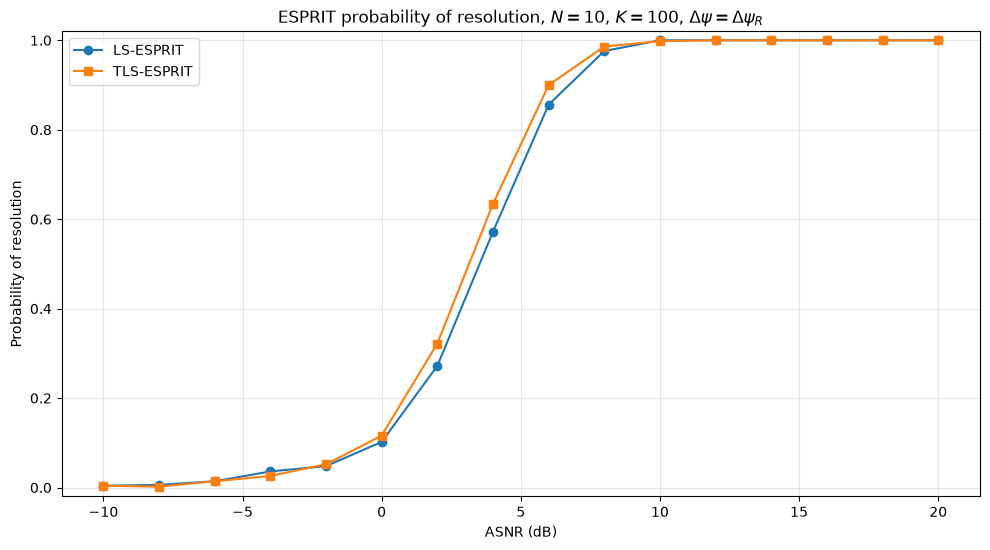

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LS/TLS-ESPRIT probability of resolution vs ASNR
# ------------------------------------------------------------

N, D, K = 10, 2, 100
n_trials = 500
asnr_db_values = np.arange(-10, 21, 2)

BW_NN = 4 * np.pi / N
delta_psi_R = 0.2165 * BW_NN
delta_psi = delta_psi_R
psi_true = np.array([-delta_psi / 2, delta_psi / 2])

n = np.arange(N)

def steering(psi):
    return np.exp(1j * n * psi)

A = np.column_stack([
    steering(p) for p in psi_true
])

def estimate_esprit(asnr_db, method, rng):
    S = (
        rng.standard_normal((D, K))
        + 1j * rng.standard_normal((D, K))
    ) / np.sqrt(2)

    noise_power = N / 10**(asnr_db / 10)

    X = A @ S + np.sqrt(noise_power / 2) * (
        rng.standard_normal((N, K))
        + 1j * rng.standard_normal((N, K))
    )

    R = X @ X.conj().T / K
    _, E = np.linalg.eigh(R)
    Es = E[:, -D:]

    E1 = Es[:-1, :]
    E2 = Es[1:, :]

    if method == "LS":
        Psi = np.linalg.pinv(E1) @ E2

    else:
        Z = np.hstack([E1, E2])
        C = Z.conj().T @ Z

        _, V = np.linalg.eigh(C)

        Vmin = V[:, :D]
        V12 = Vmin[:D, :]
        V22 = Vmin[D:, :]

        Psi = -V12 @ np.linalg.inv(V22)

    return np.sort(
        np.angle(np.linalg.eigvals(Psi))
    )

def is_resolved(psi_hat):
    return np.all(
        np.abs(psi_hat - psi_true)
        <= delta_psi / 2
    )

def resolution_curve(method, seed):
    rng = np.random.default_rng(seed)

    return np.array([
        np.mean([
            is_resolved(
                estimate_esprit(asnr, method, rng)
            )
            for _ in range(n_trials)
        ])
        for asnr in asnr_db_values
    ])

p_ls = resolution_curve("LS", seed=1)
p_tls = resolution_curve("TLS", seed=2)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.plot(
    asnr_db_values,
    p_ls,
    marker="o",
    label="LS-ESPRIT"
)

plt.plot(
    asnr_db_values,
    p_tls,
    marker="s",
    label="TLS-ESPRIT"
)

plt.xlabel("ASNR (dB)")
plt.ylabel("Probability of resolution")

plt.title(
    fr"ESPRIT probability of resolution, "
    fr"$N={N}$, $K={K}$, "
    fr"$\Delta\psi=\Delta\psi_R$"
)

plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The probability-of-resolution curves characterize the **threshold behavior** of LS- and TLS-ESPRIT. At low ASNR, noise and finite covariance support perturb the estimated signal subspace, and the two sources are not reliably resolved. Above a certain ASNR, the probability of resolution rapidly approaches one.

<a id="doa-estimation-accuracy-vs-asnr"></a>

### DoA Estimation Accuracy vs ASNR

The estimation accuracy of LS- and TLS-ESPRIT can be quantified using the **root-mean-square error (RMSE)** of the estimated spatial frequencies.

The same two-source scenario is used as for the probability-of-resolution analysis: a 10-element ULA, two equal-power uncorrelated sources, $K=100$ snapshots, and source separation

$$
\Delta\psi=\Delta\psi_R.
$$

For each ASNR value, multiple independent signal and noise realizations are generated. The estimated spatial frequencies are compared with the known source locations, and the RMSE is calculated as

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{2N_{\mathrm{trials}}}
\sum_{i=1}^{N_{\mathrm{trials}}}
\sum_{k=1}^{2}
\left(
\hat{\psi}_{k,i}-\psi_k
\right)^2
}.
$$

The following simulation compares the RMSE of **LS-ESPRIT** and **TLS-ESPRIT** for the standard overlapping subarrays with $d_s=1$.


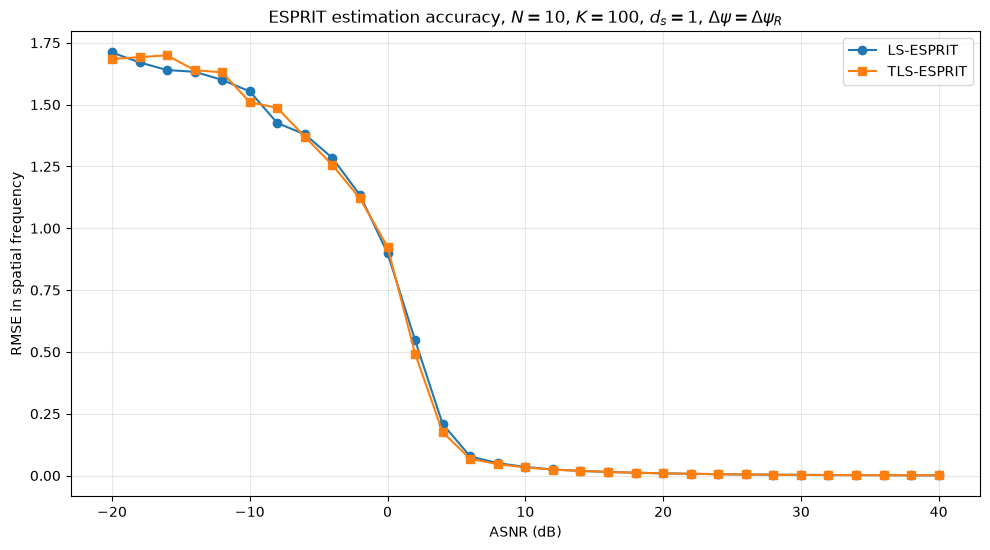

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LS/TLS-ESPRIT RMSE vs ASNR
# ------------------------------------------------------------

N, D, K = 10, 2, 100
n_trials = 500
asnr_db_values = np.arange(-20, 41, 2)
ds = 1

BW_NN = 4 * np.pi / N
delta_psi = 0.2165 * BW_NN
psi_true = np.array([-delta_psi / 2, delta_psi / 2])

n = np.arange(N)

def steering(psi):
    return np.exp(1j * n * psi)

A = np.column_stack([steering(p) for p in psi_true])

def estimate_esprit(asnr_db, method, rng):
    S = (
        rng.standard_normal((D, K))
        + 1j * rng.standard_normal((D, K))
    ) / np.sqrt(2)

    noise_power = N / 10**(asnr_db / 10)

    X = A @ S + np.sqrt(noise_power / 2) * (
        rng.standard_normal((N, K))
        + 1j * rng.standard_normal((N, K))
    )

    R = X @ X.conj().T / K
    _, E = np.linalg.eigh(R)
    Es = E[:, -D:]

    E1 = Es[:-1, :]
    E2 = Es[1:, :]

    if method == "LS":
        Psi = np.linalg.pinv(E1) @ E2
    else:
        Z = np.hstack([E1, E2])
        C = Z.conj().T @ Z
        _, V = np.linalg.eigh(C)

        Vmin = V[:, :D]
        V12 = Vmin[:D, :]
        V22 = Vmin[D:, :]

        Psi = -V12 @ np.linalg.inv(V22)

    return np.sort(
        np.angle(np.linalg.eigvals(Psi))
    )

def rmse_curve(method, seed):
    rng = np.random.default_rng(seed)
    rmse = []

    for asnr in asnr_db_values:
        errors = []

        for _ in range(n_trials):
            psi_hat = estimate_esprit(asnr, method, rng)
            errors.extend(psi_hat - psi_true)

        rmse.append(
            np.sqrt(np.mean(np.square(errors)))
        )

    return np.array(rmse)

rmse_ls = rmse_curve("LS", seed=1)
rmse_tls = rmse_curve("TLS", seed=2)

plt.figure(figsize=(10, 5.6))

plt.plot(
    asnr_db_values,
    rmse_ls,
    marker="o",
    label="LS-ESPRIT"
)

plt.plot(
    asnr_db_values,
    rmse_tls,
    marker="s",
    label="TLS-ESPRIT"
)

plt.xlabel("ASNR (dB)")
plt.ylabel("RMSE in spatial frequency")
plt.title(
    fr"ESPRIT estimation accuracy, "
    fr"$N={N}$, $K={K}$, $d_s={ds}$, "
    fr"$\Delta\psi=\Delta\psi_R$"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The RMSE decreases as ASNR increases because the estimated covariance matrix and signal subspace become progressively less affected by noise.

At low ASNR, the estimated signal subspace is strongly perturbed and ESPRIT can enter a threshold region in which the estimated phase shifts deviate substantially from the true source locations. Above this region, the RMSE decreases smoothly with increasing ASNR.

LS- and TLS-ESPRIT show similar high-ASNR behavior. Their main difference is expected near the threshold region, where TLS can be more robust because it accounts for estimation errors in both subarray signal-subspace matrices.

<a id="validation-results-with-awr2243"></a>

### Validation Results with AWR2243

The ESPRIT LS and TLS implementations are validated using real measurements acquired with the **AWR2243** radar in two-target broadside and off-boresight scenarios. For comparison, the ESPRIT detections are shown together with the Capon/MVDR, MUSIC, and conventional FFT beamformer responses using the same covariance snapshots.

<p align="center">
  <img
    src="../docs/images/esprit_broadside.png"
    alt="FFT, ESPRIT, Capon and MUSIC comparison for the broadside scenario"
    width="95%">
</p>

<p align="center">
  <img
    src="../docs/images/esprit_offboresight.png"
    alt="FFT, ESPRIT, Capon and MUSIC comparison for the off-boresight scenario"
    width="95%">
</p>

According to the Rayleigh resolution criterion, the theoretical angular resolution of the FFT beamformer is approximately $14.84^\circ$ for the broadside scenario and $20.76^\circ$ for the off-boresight scenario, corresponding to lateral separations of approximately $1.8$ m and $2.5$ m, respectively.

In the measurements, the corner reflectors are separated by only $1.0$ m in the broadside case and $2.0$ m in the off-boresight case. Both separations are therefore below the corresponding theoretical FFT resolution limits.

Despite this, ESPRIT (both LS and TLS), MUSIC, and Capon/MVDR provide consistent DoA estimates and clearly resolve the two targets, while the conventional FFT beamformer cannot explicitly separate them.